In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

In [2]:
#read the complete dataset as compiled in read_spiff
combined_df = pd.read_pickle('spiff_all.pkl')

In [3]:
final_array = combined_df.T.to_numpy()
print(f"Array Shape: {final_array.shape}") # (Number of files, Number of unique x points)

Array Shape: (10473, 102)


In [4]:
#should we try analyzing only the previous known brown dwarfs with spectroscopy?  
# I know this is the first 2304 files.  
# .iloc[:, :2304] means "keep all rows, but only columns from index 0 up to 2304"
subset_df = combined_df.iloc[:, :2304]

# If you need the 2D NumPy array for PCA on just these files:
subset_array = subset_df.T.to_numpy()

print(f"Original shape: {combined_df.shape}")
print(f"New shape: {subset_df.shape}")
# we make no use of this
#
# remaining notebook is BOTH known-with-spectroscopy and known-from-photometry-only

Original shape: (102, 10473)
New shape: (102, 2304)


In [5]:
#Some stuff that was useful
filenames=combined_df.columns.tolist()
x_values = combined_df.index.to_numpy()
oid_list = [re.search(r'moca_oid_(\d+)', f).group(1) for f in filenames if 'moca_oid_' in f]
all_oids = np.array(combined_df.columns) # Convert list to numpy array 
#
# need to think if you need a versopn for only known brown dwarfs

In [6]:
#experiment with removing huge positive spikes
# Calculate mean and std for each row (file)
row_means = combined_df.mean(axis=0)
row_stds = combined_df.std(axis=0)

# Define a threshold (e.g., 5 sigma)
threshold = 3
#
# Note: have experimented with this. 10 sigma is too big, the PCA components become spikes
#   5 seems okay for firs three components

# Mask points that are too far from the mean
# This keeps the shape of your data but hides the spikes
df_cleaned = combined_df.mask((combined_df - row_means).abs() > threshold * row_stds)

# Optional: Interpolate the now-missing spikes so PCA doesn't break
df_cleaned = df_cleaned.interpolate(axis=0).ffill().bfill()

In [7]:
print(row_means)

/Users/gizis/data/SPIFF/known_bds/csv/ULAS_J011151.89-010534.2_moca_oid_369154_spt_L3.5_spherex_spectrum.csv                  1.617431e-16
/Users/gizis/data/SPIFF/known_bds/csv/SDSS_J103428.24414000.7_moca_oid_370266_spt_L0_spherex_spectrum.csv                     3.356429e-16
/Users/gizis/data/SPIFF/known_bds/csv/SDSS_J135327.06650944.5_moca_oid_370833_spt_L0_spherex_spectrum.csv                     2.589437e-16
/Users/gizis/data/SPIFF/known_bds/csv/WISEA_J035843.03103939.5_moca_oid_574254_spt_L3_spherex_spectrum.csv                    6.766488e-16
/Users/gizis/data/SPIFF/known_bds/csv/SDSS_J040100.96-060933.0_moca_oid_369529_spt_L4_spherex_spectrum.csv                    2.314206e-16
                                                                                                                                  ...     
/Users/gizis/data/SPIFF/photo_known_bds/csv/CWISE_J095026.65831624.2_moca_oid_4510087_spt_unknown_spt_spherex_spectrum.csv    3.551432e-16
/Users/gizis/data/SPIFF/pho

In [8]:
# Calculate the mean for each column (file)
column_means = df_cleaned.mean(axis=0)

# Divide each column by its own mean
# Result: Every column now has a mean of 1.0
df_normalized = df_cleaned/ column_means

In [9]:
print(column_means)

/Users/gizis/data/SPIFF/known_bds/csv/ULAS_J011151.89-010534.2_moca_oid_369154_spt_L3.5_spherex_spectrum.csv                  1.608740e-16
/Users/gizis/data/SPIFF/known_bds/csv/SDSS_J103428.24414000.7_moca_oid_370266_spt_L0_spherex_spectrum.csv                     3.213255e-16
/Users/gizis/data/SPIFF/known_bds/csv/SDSS_J135327.06650944.5_moca_oid_370833_spt_L0_spherex_spectrum.csv                     2.591489e-16
/Users/gizis/data/SPIFF/known_bds/csv/WISEA_J035843.03103939.5_moca_oid_574254_spt_L3_spherex_spectrum.csv                    6.693493e-16
/Users/gizis/data/SPIFF/known_bds/csv/SDSS_J040100.96-060933.0_moca_oid_369529_spt_L4_spherex_spectrum.csv                    2.245268e-16
                                                                                                                                  ...     
/Users/gizis/data/SPIFF/photo_known_bds/csv/CWISE_J095026.65831624.2_moca_oid_4510087_spt_unknown_spt_spherex_spectrum.csv    3.586854e-16
/Users/gizis/data/SPIFF/pho

In [10]:
#final_array = df_cleaned.T.to_numpy()
final_array = df_normalized.T.to_numpy()

print(f"Array Shape: {final_array.shape}") # (Number of files, Number of unique x points)

Array Shape: (10473, 102)


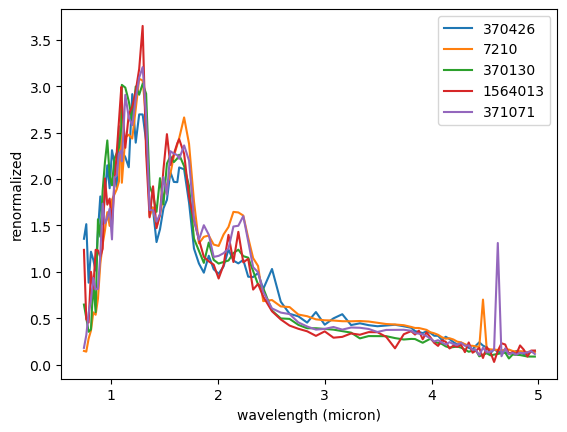

In [11]:
plt.plot(x_values, final_array[100]/np.nanmean(final_array[100]),label=oid_list[100]) 
plt.plot(x_values, final_array[101]/np.nanmean(final_array[101]),label=oid_list[101]) 
plt.plot(x_values, final_array[102]/np.nanmean(final_array[102]),label=oid_list[102]) 
plt.plot(x_values, final_array[103]/np.nanmean(final_array[103]),label=oid_list[103]) 
plt.plot(x_values, final_array[104]/np.nanmean(final_array[104]),label=oid_list[104]) 
plt.xlabel('wavelength (micron)')
plt.ylabel("renormalized")
plt.legend()
plt.show()

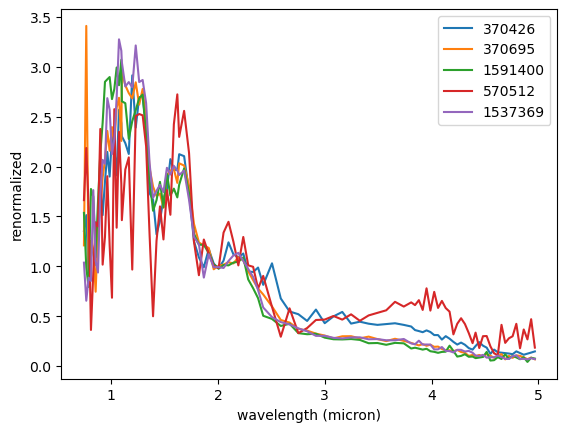

In [12]:
plt.plot(x_values, final_array[100],label=oid_list[100]) 
plt.plot(x_values, final_array[3101],label=oid_list[2101]) 
plt.plot(x_values, final_array[4102],label=oid_list[4102]) 
plt.plot(x_values, final_array[5103],label=oid_list[5103]) 
plt.plot(x_values, final_array[6104],label=oid_list[6104]) 
plt.xlabel('wavelength (micron)')
plt.ylabel("renormalized")
plt.legend()
plt.show()

In [13]:
#
# shameless use Gemini AI for coding.
#  although indeed I have done this before on other datasets.
#
# preprocess datasets. 
#  will interpolate rather than set NaN to zero.
#
# It seems clear the spectra include a few huge outliers. 
#   rather than clean individually at this point, try the robust scaler
#
# X is your (samples, features) array

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

# 1. Prepare the data (Rows = Samples/Files, Columns = X-values)
# We use .T because scikit-learn expects (n_samples, n_features)
X = df_normalized.T.copy()

# 2. Fill NaNs
# Option A: Fill with 0
#X_filled = X.fillna(0) 
# Option B: Interpolate (better for spectra)
X_filled = X.interpolate(axis=1).fillna(0)

# 3. Standardize the data (Mean=0, Variance=1)
#scaler = StandardScaler()
# use the robust scaler
#scaler = RobustScaler()
#X_scaled = scaler.fit_transform(X_filled)
# all the scaling is not helpful for spectroscopic data. 
#
X_scaled=X_filled

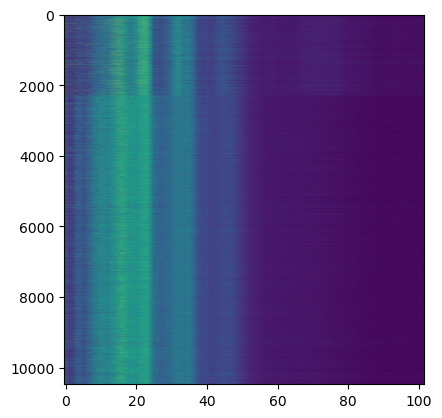

In [14]:
plt.imshow(X_scaled,aspect=0.01,vmin=0,vmax=5)
#not the worrisome fact that previously unknown seem systematically different. probably earlier type on average?
# probably fainter?  

In [15]:
print(np.max(X_scaled),np.min(X_scaled))

23.393290022802493 1.71479465520291e-10


In [16]:
X_scaled.max(axis=1)

/Users/gizis/data/SPIFF/known_bds/csv/ULAS_J011151.89-010534.2_moca_oid_369154_spt_L3.5_spherex_spectrum.csv                  2.638538
/Users/gizis/data/SPIFF/known_bds/csv/SDSS_J103428.24414000.7_moca_oid_370266_spt_L0_spherex_spectrum.csv                     3.427398
/Users/gizis/data/SPIFF/known_bds/csv/SDSS_J135327.06650944.5_moca_oid_370833_spt_L0_spherex_spectrum.csv                     3.336429
/Users/gizis/data/SPIFF/known_bds/csv/WISEA_J035843.03103939.5_moca_oid_574254_spt_L3_spherex_spectrum.csv                    2.799647
/Users/gizis/data/SPIFF/known_bds/csv/SDSS_J040100.96-060933.0_moca_oid_369529_spt_L4_spherex_spectrum.csv                    3.603615
                                                                                                                                ...   
/Users/gizis/data/SPIFF/photo_known_bds/csv/CWISE_J095026.65831624.2_moca_oid_4510087_spt_unknown_spt_spherex_spectrum.csv    3.133647
/Users/gizis/data/SPIFF/photo_known_bds/csv/2MASS_J0225

In [17]:
# Create PCA object - let's look at the top 5 components
pca = PCA(n_components=5)

# Fit and transform the scaled data
pca_features = pca.fit_transform(X_scaled)

# Check how much information (variance) we kept
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
#
# save the loading
pc1_loading = pca.components_[0]
pc2_loading = pca.components_[1]
pc3_loading = pca.components_[2]
pc4_loading = pca.components_[3]
pc5_loading = pca.components_[4]


Explained variance ratio: [0.25789577 0.20277598 0.09963033 0.03871979 0.0284029 ]


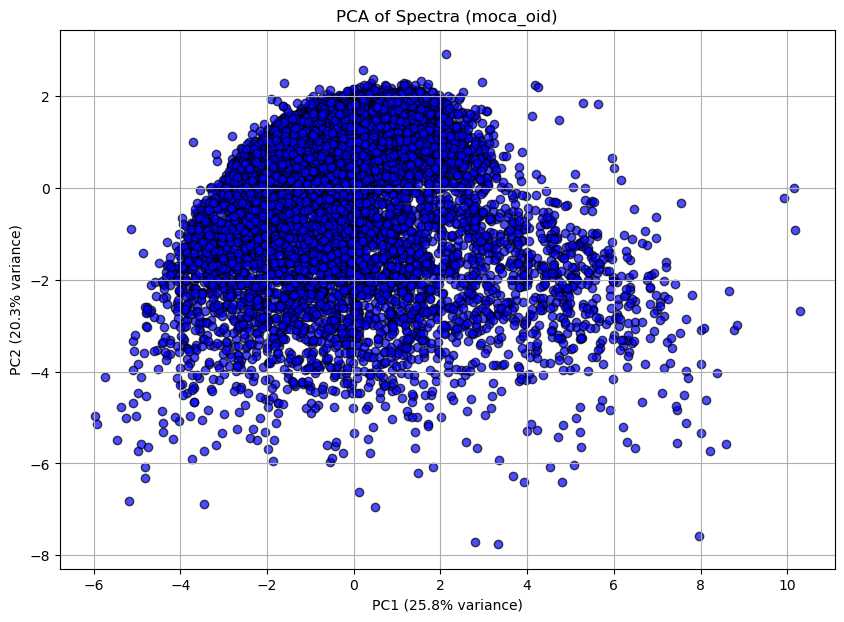

In [18]:
plt.figure(figsize=(10, 7))
plt.scatter(pca_features[:, 0], pca_features[:, 1], alpha=0.7, c='blue', edgecolors='k')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA of Spectra (moca_oid)')
plt.grid(True)
plt.show()

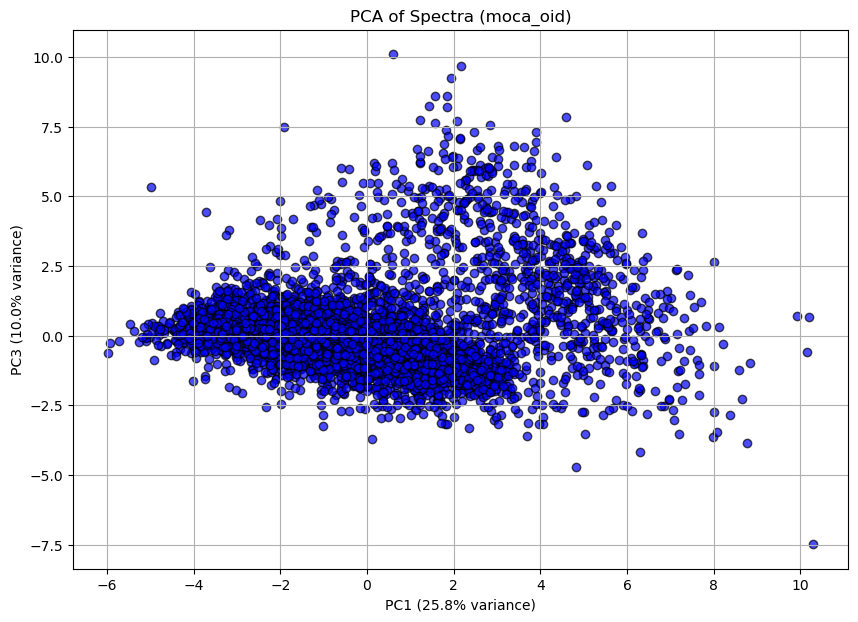

In [19]:
plt.figure(figsize=(10, 7))
plt.scatter(pca_features[:, 0], pca_features[:, 2], alpha=0.7, c='blue', edgecolors='k')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%} variance)')
plt.title('PCA of Spectra (moca_oid)')
plt.grid(True)
plt.show()

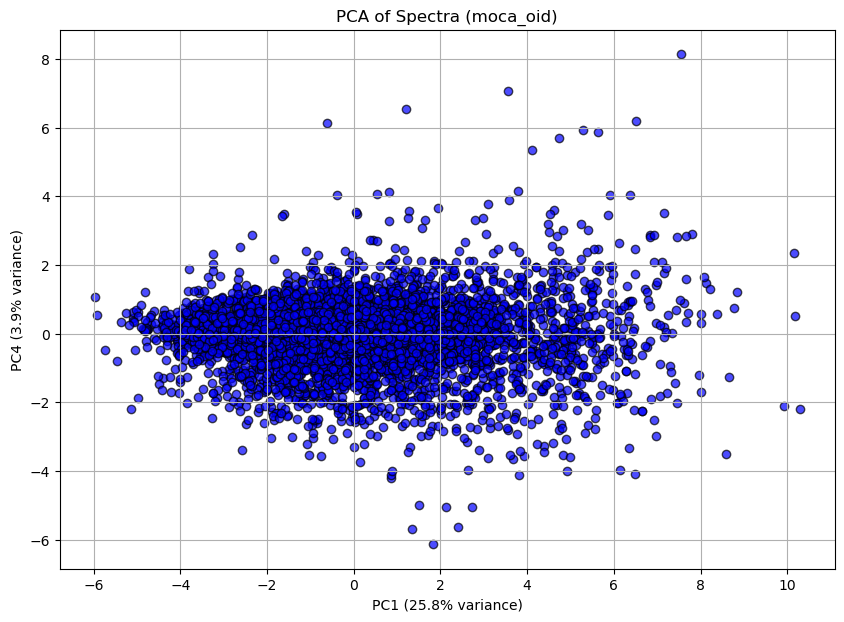

In [20]:
plt.figure(figsize=(10, 7))
plt.scatter(pca_features[:, 0], pca_features[:, 3], alpha=0.7, c='blue', edgecolors='k')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC4 ({pca.explained_variance_ratio_[3]:.1%} variance)')
plt.title('PCA of Spectra (moca_oid)')
plt.grid(True)
plt.show()

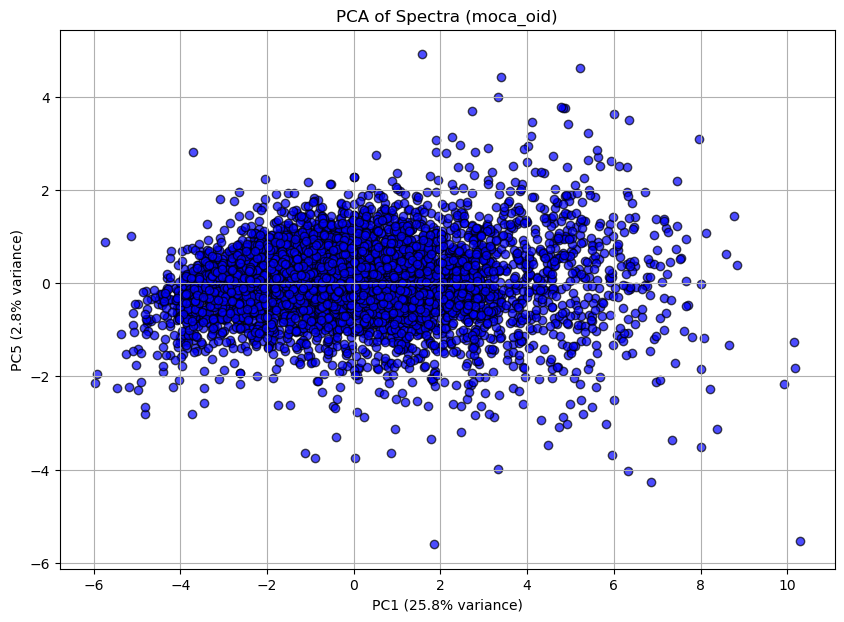

In [21]:
plt.figure(figsize=(10, 7))
plt.scatter(pca_features[:, 0], pca_features[:, 4], alpha=0.7, c='blue', edgecolors='k')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC5 ({pca.explained_variance_ratio_[4]:.1%} variance)')
plt.title('PCA of Spectra (moca_oid)')
plt.grid(True)
plt.show()

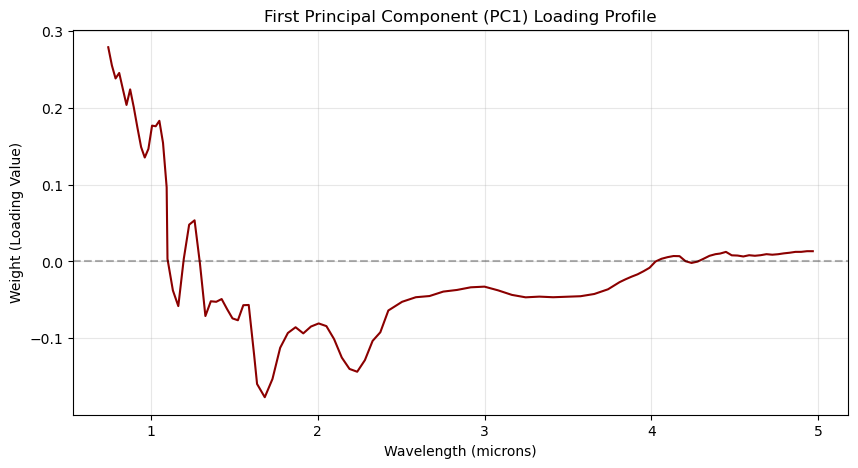

In [22]:

plt.figure(figsize=(10, 5))
plt.plot(x_values, pc1_loading, color='darkred', lw=1.5)

plt.axhline(0, color='black', linestyle='--', alpha=0.3) # Reference line at 0
plt.title('First Principal Component (PC1) Loading Profile')
plt.xlabel('Wavelength (microns)')
plt.ylabel('Weight (Loading Value)')
plt.grid(True, alpha=0.3)
plt.show()

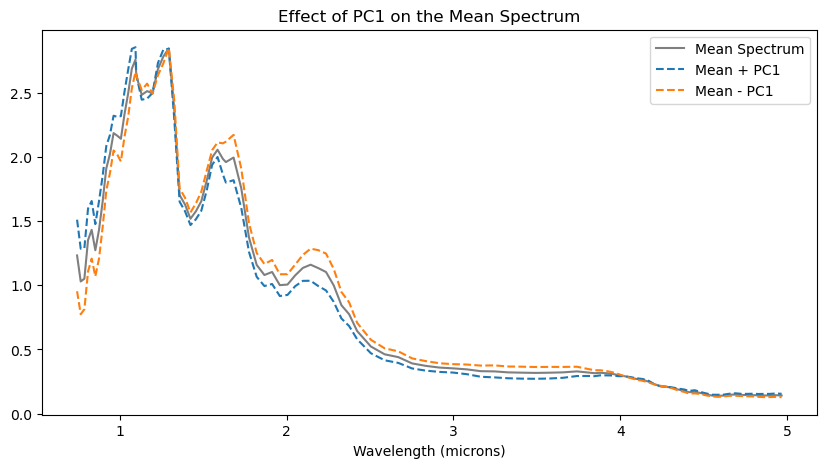

In [23]:
# Calculate the mean of your scaled data
mean_spectrum = X_scaled.mean(axis=0)

plt.figure(figsize=(10, 5))
plt.plot(x_values, mean_spectrum, label='Mean Spectrum', color='black', alpha=0.5)
plt.plot(x_values, mean_spectrum + pc1_loading, label='Mean + PC1', linestyle='--')
plt.plot(x_values, mean_spectrum - pc1_loading, label='Mean - PC1', linestyle='--')

plt.title('Effect of PC1 on the Mean Spectrum')
plt.xlabel('Wavelength (microns)')

plt.legend()
plt.show()

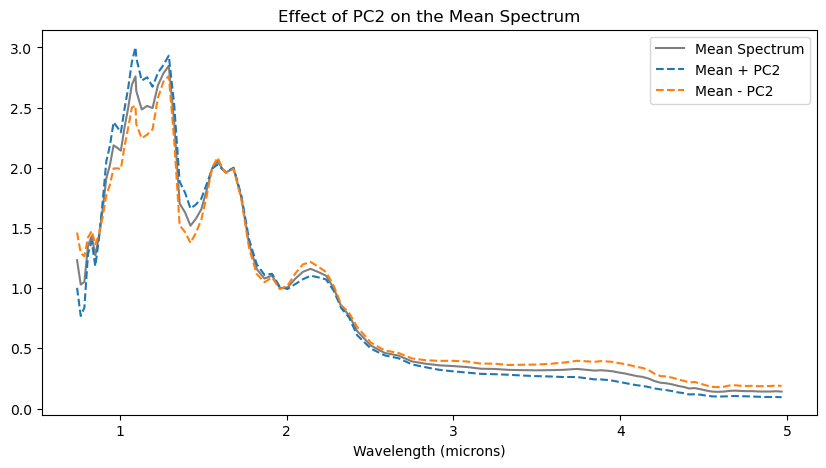

In [24]:

plt.figure(figsize=(10, 5))
plt.plot(x_values, mean_spectrum, label='Mean Spectrum', color='black', alpha=0.5)
plt.plot(x_values, mean_spectrum + pc2_loading, label='Mean + PC2', linestyle='--')
plt.plot(x_values, mean_spectrum - pc2_loading, label='Mean - PC2', linestyle='--')
plt.xlabel('Wavelength (microns)')
plt.title('Effect of PC2 on the Mean Spectrum')
plt.legend()
plt.show()

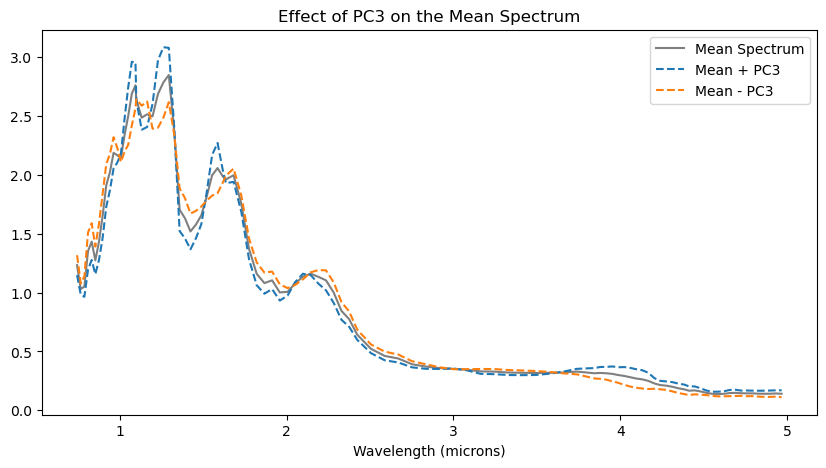

In [25]:
#
plt.figure(figsize=(10, 5))
plt.plot(x_values, mean_spectrum, label='Mean Spectrum', color='black', alpha=0.5)
plt.plot(x_values, mean_spectrum + pc3_loading, label='Mean + PC3', linestyle='--')
plt.plot(x_values, mean_spectrum - pc3_loading, label='Mean - PC3', linestyle='--')
plt.xlabel('Wavelength (microns)')
plt.title('Effect of PC3 on the Mean Spectrum')
plt.legend()
plt.show()

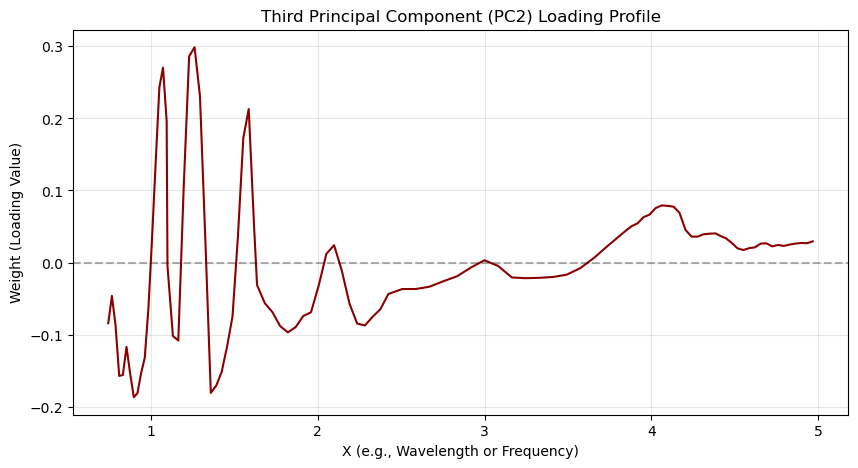

In [26]:
# pca.components_[0] is the weight of each x-value in PC1
pc3_loading = pca.components_[2]

plt.figure(figsize=(10, 5))
plt.plot(x_values, pc3_loading, color='darkred', lw=1.5)

plt.axhline(0, color='black', linestyle='--', alpha=0.3) # Reference line at 0
plt.title('Third Principal Component (PC2) Loading Profile')
plt.xlabel('X (e.g., Wavelength or Frequency)')
plt.ylabel('Weight (Loading Value)')
plt.grid(True, alpha=0.3)
plt.show()

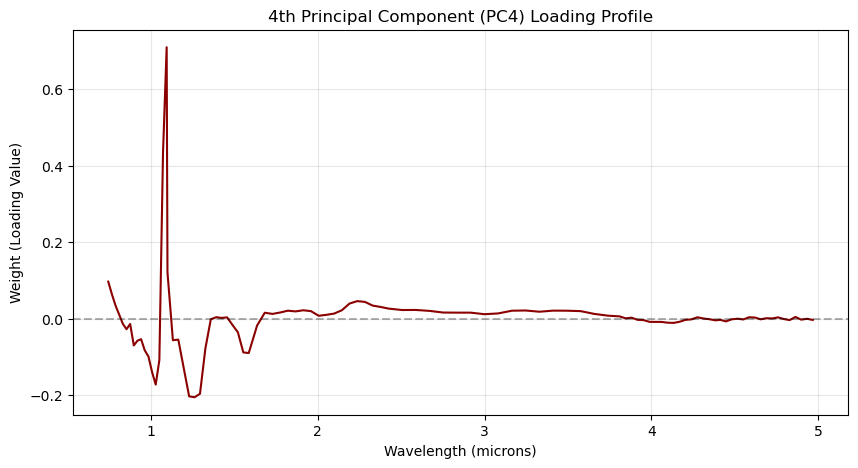

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(x_values, pc4_loading, color='darkred', lw=1.5)

plt.axhline(0, color='black', linestyle='--', alpha=0.3) # Reference line at 0
plt.title('4th Principal Component (PC4) Loading Profile')
plt.xlabel('Wavelength (microns)')
plt.ylabel('Weight (Loading Value)')
plt.grid(True, alpha=0.3)
plt.show()

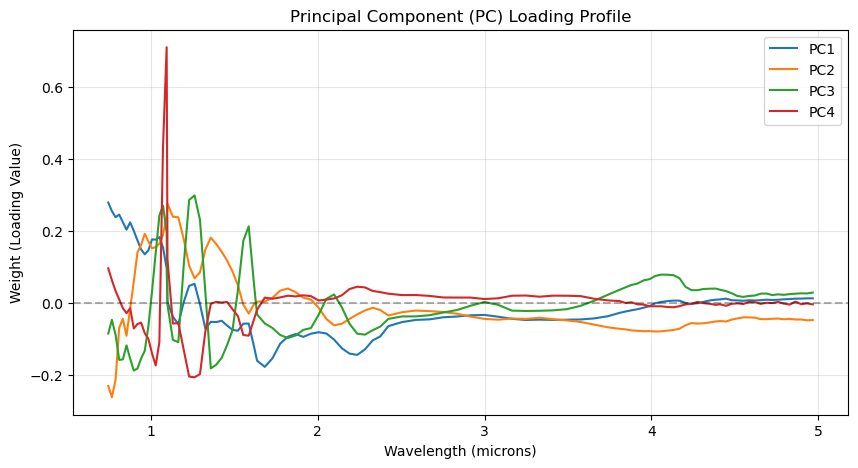

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(x_values, pc1_loading, lw=1.5, label='PC1')
plt.plot(x_values, pc2_loading,  lw=1.5, label='PC2')
plt.plot(x_values, pc3_loading,  lw=1.5, label='PC3')
plt.plot(x_values, pc4_loading,  lw=1.5, label='PC4')
#
plt.axhline(0, color='black', linestyle='--', alpha=0.3) # Reference line at 0
plt.title('Principal Component (PC) Loading Profile')
plt.xlabel('Wavelength (microns)')
plt.ylabel('Weight (Loading Value)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

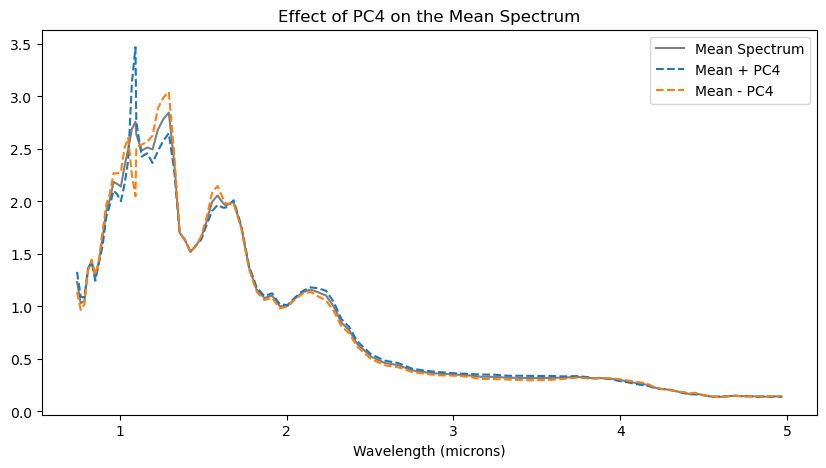

In [29]:
#
plt.figure(figsize=(10, 5))
plt.plot(x_values, mean_spectrum, label='Mean Spectrum', color='black', alpha=0.5)
plt.plot(x_values, mean_spectrum + pc4_loading, label='Mean + PC4', linestyle='--')
plt.plot(x_values, mean_spectrum - pc4_loading, label='Mean - PC4', linestyle='--')
plt.xlabel('Wavelength (microns)')
plt.title('Effect of PC4 on the Mean Spectrum')
plt.legend()
plt.show()

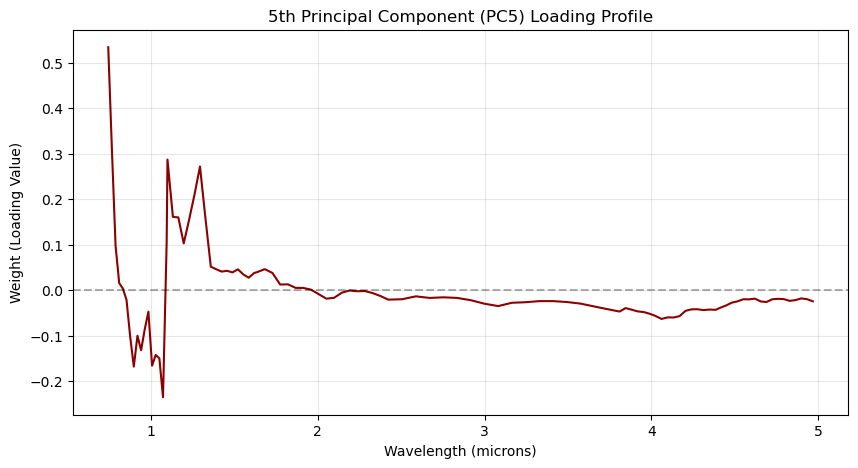

In [30]:

plt.figure(figsize=(10, 5))
plt.plot(x_values, pc5_loading, color='darkred', lw=1.5)

plt.axhline(0, color='black', linestyle='--', alpha=0.3) # Reference line at 0
plt.title('5th Principal Component (PC5) Loading Profile')
plt.xlabel('Wavelength (microns)')
plt.ylabel('Weight (Loading Value)')
plt.grid(True, alpha=0.3)
plt.show()

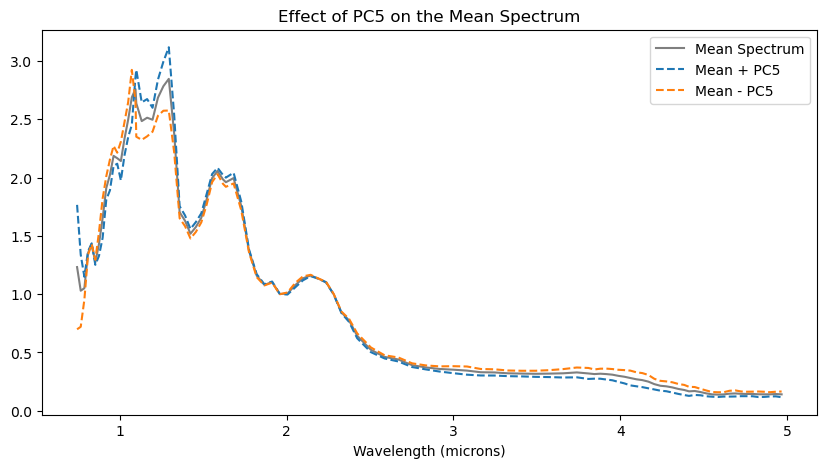

In [31]:
#
plt.figure(figsize=(10, 5))
plt.plot(x_values, mean_spectrum, label='Mean Spectrum', color='black', alpha=0.5)
plt.plot(x_values, mean_spectrum + pc5_loading, label='Mean + PC5', linestyle='--')
plt.plot(x_values, mean_spectrum - pc5_loading, label='Mean - PC5', linestyle='--')
plt.xlabel('Wavelength (microns)')
plt.title('Effect of PC5 on the Mean Spectrum')
plt.legend()
plt.show()

In [32]:
# Human analysis:
# PC1 the main L dwarf spectral features
# PC2 makes source redder/bluer
# PC3 methane
# PC4, PC5 an emission line that is probably a data error but should be checked, mixing in some real features
#
# these change as different preprocessing is used! So this comment could be out of date

In [33]:
#find outliers
#
# this was used previously to identify some problematic spectra.
#
# the offending outlier points have been removed from the ascii spectra and hence the pickle.
#
# but here are some of the interesting outliers
#
i_PC4 = (pca_features[:, 3] > 6)
weirdPC4_oids = all_oids[i_PC4]


In [34]:
#weirdPC4_oids


In [35]:
weirdPC4_data = final_array[i_PC4, :]

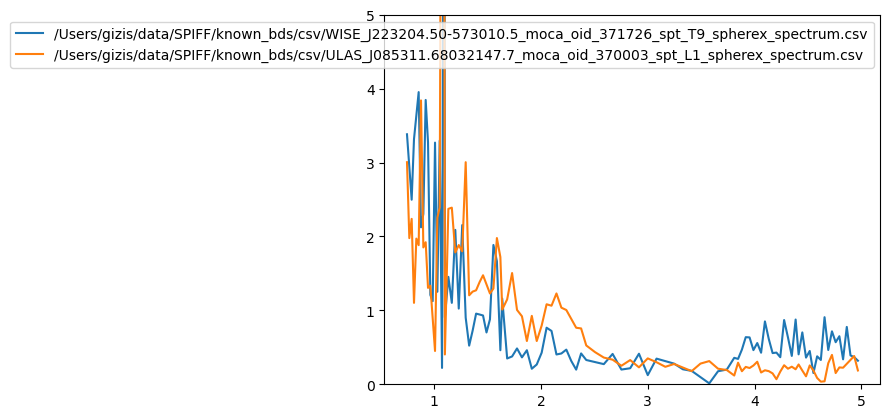

In [36]:
plt.plot(x_values,weirdPC4_data[0],label=weirdPC4_oids[0])
plt.plot(x_values,weirdPC4_data[1],label=weirdPC4_oids[1])
plt.ylim(0,5)
plt.legend()


In [37]:
#look at the outliers. however, the horrendous ones have been removed previously
i_PC5 = (pca_features[:, 4] > 4)
weirdPC5_oids = all_oids[i_PC5]
weirdPC5_data = final_array[i_PC5, :]
print(weirdPC5_oids)

['/Users/gizis/data/SPIFF/photo_known_bds/csv/CWISE_J133501.53-585351.2_moca_oid_572655_spt_unknown_spt_spherex_spectrum.csv'
 '/Users/gizis/data/SPIFF/photo_known_bds/csv/CFBDS_J151929105059_moca_oid_4508121_spt_L0-Y2_spherex_spectrum.csv'
 '/Users/gizis/data/SPIFF/photo_known_bds/csv/CWISE_J034754.78-193012.7_moca_oid_571092_spt_unknown_spt_spherex_spectrum.csv']


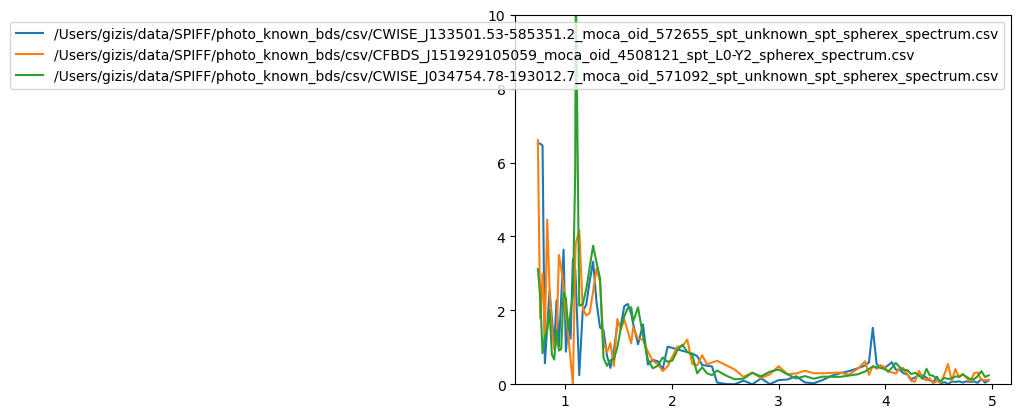

In [38]:
plt.plot(x_values,weirdPC5_data[0],label=weirdPC5_oids[0])
plt.plot(x_values,weirdPC5_data[1],label=weirdPC5_oids[1])
plt.plot(x_values,weirdPC5_data[2],label=weirdPC5_oids[2])
#plt.plot(x_values,weirdPC5_data[1],label=weirdPC5_oids[1])
plt.ylim(0,10)
#plt.xlim(0.7,1.0)
plt.legend()